# Notebook 12 — 投影简并打破 / Degeneracy Breaking (Fig 15)

## 实验目标 / Objective

球面投影存在径向简并：不同 3D 场可投影出相同 2D 球面图。
本实验通过双胞胎实验验证 3D 锚点能否打破此简并。

Spherical projection has radial degeneracy: different 3D fields can project
to the same 2D sphere map. This twin experiment tests whether 3D anchor
points can break this degeneracy.

## 实验设计 / Experimental Design
- 48^3 已知真值 (ground truth)
- Exp A: 仅用北半球训练，南半球测试
- Exp B: 北半球 + 25% 3D 锚点训练，南半球测试

## 对应论文图表 / Paper Figure
- **Fig 15**: 2x2 scatter plots (train/test for A and B)

## 预期结果 / Expected Results
- Exp A 测试集: r = -0.06 (无法泛化)
- Exp B 测试集: r = 0.41 (锚点打破简并)

In [1]:
# ── Environment Setup / Environment Setup ──────────────────────────
import sys, os, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '../src')
from dsc_engine import *

# JAX 配置 / JAX configuration
try:
    import jax
    jax.config.update('jax_enable_x64', True)
    import jax.numpy as jnp
    from jax import grad, jit, random
    print(f"JAX backend: {jax.default_backend()}")
except ImportError:
    raise ImportError("本 notebook 需要 JAX / This notebook requires JAX: pip install jax")

import numpy as np
import matplotlib.pyplot as plt
import healpy as hp

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

ERROR:2026-04-09 13:24:56,255:jax._src.xla_bridge:487: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/root/miniconda3/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 485, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/root/miniconda3/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/root/miniconda3/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.


JAX backend: cpu


## 1. 生成已知真值 / Generate Ground Truth

使用 48^3 DSC 3D 演化生成已知的 ground truth 场，
然后投影到 HEALPix 球面作为"观测"数据。

In [2]:
# ── 参数 / Parameters ────────────────────────────────────
N_vox = 48        # 3D 体素边长 / 3D voxel grid side
NSIDE = 16        # HEALPix 分辨率 / HEALPix resolution
n_steps = 25      # 演化Steps / evolution steps
c2_base = 0.45
c0 = 10.0
drag = 0.015
lr = 0.2
epochs_A = 120    # Exp A 优化轮数
epochs_B = 120    # Exp B 优化轮数
lambda_TV = 0.002
anchor_frac = 0.25  # 3D Anchors比例 / 3D anchor fraction

NPIX = hp.nside2npix(NSIDE)

# ── 生成 ground truth / Generate ground truth ────────────
phi0_true = generate_initial_3d(N_vox, seed=77)
phi_true_final = evolve_symplectic_3d(phi0_true, n_steps=n_steps,
                                       c2_base=c2_base, c0=c0, drag=drag)
print(f"Ground truth Generation complete: {N_vox}^3 voxels")

# ── 投影设置 / Projection setup ──────────────────────────
theta_hp, phi_hp_arr = hp.pix2ang(NSIDE, np.arange(NPIX))
R_shell = N_vox // 4
center = N_vox / 2.0
dx = np.sin(theta_hp) * np.cos(phi_hp_arr)
dy = np.sin(theta_hp) * np.sin(phi_hp_arr)
dz = np.cos(theta_hp)

n_shells = 3
radii = np.linspace(R_shell - 2, R_shell + 2, n_shells)
ix_all = [np.clip((center + r * dx).astype(int), 0, N_vox-1) for r in radii]
iy_all = [np.clip((center + r * dy).astype(int), 0, N_vox-1) for r in radii]
iz_all = [np.clip((center + r * dz).astype(int), 0, N_vox-1) for r in radii]
ix_j = jnp.array(np.stack(ix_all))
iy_j = jnp.array(np.stack(iy_all))
iz_j = jnp.array(np.stack(iz_all))

def project_hp(phi3d):
    """投影到 HEALPix / Project to HEALPix."""
    vals = jnp.zeros(NPIX)
    for s in range(n_shells):
        vals = vals + phi3d[ix_j[s], iy_j[s], iz_j[s]]
    vals = vals / n_shells
    return (vals - vals.mean()) / (vals.std() + 1e-15)

# 生成 ground truth 球面图 / Generate ground truth sphere map
target_full = np.array(project_hp(jnp.array(phi_true_final)))

# ── 南North Hemisphere划分 / North-South hemisphere split ──────────
north_mask = theta_hp < np.pi / 2  # North Hemisphere: theta < pi/2
south_mask = ~north_mask
print(f"North Hemisphere/ North pixels: {north_mask.sum()}, South Hemisphere / South: {south_mask.sum()}")

# ── 3D Anchors / 3D anchor points ──────────────────────────
np.random.seed(42)
n_anchors = int(anchor_frac * N_vox**3)
anchor_idx = np.random.choice(N_vox**3, n_anchors, replace=False)
anchor_vals = phi_true_final.ravel()[anchor_idx]
anchor_idx_jax = jnp.array(anchor_idx)
anchor_vals_jax = jnp.array(anchor_vals)
print(f"3D Anchors/ 3D anchors: {n_anchors} ({anchor_frac*100:.0f}% of {N_vox}^3)")

Ground truth Generation complete: 48^3 voxels


North Hemisphere/ North pixels: 1504, South Hemisphere / South: 1568
3D Anchors/ 3D anchors: 27648 (25% of 48^3)


## 2. DSC 正向模型与损失函数 / DSC Forward Model & Loss Functions

Exp A: Loss = MSE(北半球像素) + TV
Exp B: Loss = MSE(北半球像素) + MSE(3D锚点) + TV

In [3]:
# ── JAX 正向模型 / JAX forward model ─────────────────────
def laplacian_3d_jax(phi):
    return (jnp.roll(phi, 1, 0) + jnp.roll(phi, -1, 0) +
            jnp.roll(phi, 1, 1) + jnp.roll(phi, -1, 1) +
            jnp.roll(phi, 1, 2) + jnp.roll(phi, -1, 2) - 6.0 * phi) / 6.0

def dsc_forward(phi0, n_steps=25):
    phi = phi0; phi_prev = phi0
    for t in range(1, n_steps + 1):
        c2_t = c2_base / jnp.log(t + c0)**2
        lap = laplacian_3d_jax(phi)
        phi_new = 2.0*phi - phi_prev + c2_t*lap - drag*(phi - phi_prev)
        phi_new = jnp.clip(phi_new, -5.0, 5.0)
        phi_prev = phi; phi = phi_new
    return phi

def tv_3d(phi):
    return (jnp.mean((phi[1:,:,:]-phi[:-1,:,:])**2) +
            jnp.mean((phi[:,1:,:]-phi[:,:-1,:])**2) +
            jnp.mean((phi[:,:,1:]-phi[:,:,:-1])**2))

target_jax = jnp.array(target_full)
north_jax = jnp.array(north_mask)
south_jax = jnp.array(south_mask)

# ── Exp A 损失: 仅North Hemisphere / Exp A loss: north hemisphere only ──
def loss_A(phi0_flat):
    phi0 = phi0_flat.reshape(N_vox, N_vox, N_vox)
    phi_f = dsc_forward(phi0, n_steps)
    pred = project_hp(phi_f)
    # 仅North Hemisphere MSE / North hemisphere MSE only
    diff = (pred - target_jax) * north_jax
    mse = jnp.sum(diff**2) / jnp.sum(north_jax)
    return mse + lambda_TV * tv_3d(phi0)

# ── Exp B 损失: North Hemisphere + 3D Anchors / Exp B loss: north + 3D anchors ──
def loss_B(phi0_flat):
    phi0 = phi0_flat.reshape(N_vox, N_vox, N_vox)
    phi_f = dsc_forward(phi0, n_steps)
    pred = project_hp(phi_f)
    # North Hemisphere MSE / North hemisphere MSE
    diff = (pred - target_jax) * north_jax
    mse_north = jnp.sum(diff**2) / jnp.sum(north_jax)
    # 3D Anchors MSE / 3D anchor MSE
    pred_3d_flat = phi_f.ravel()
    anchor_diff = pred_3d_flat[anchor_idx_jax] - anchor_vals_jax
    mse_anchor = jnp.mean(anchor_diff**2)
    return mse_north + 0.5 * mse_anchor + lambda_TV * tv_3d(phi0)

grad_A = jit(grad(loss_A))
grad_B = jit(grad(loss_B))
loss_A_jit = jit(loss_A)
loss_B_jit = jit(loss_B)

print("/ Loss functions defined")

/ Loss functions defined


## 3. 运行双胞胎实验 / Run Twin Experiments

In [4]:
# ── Adam 优化器 / Adam optimizer ─────────────────────────
def adam_run(loss_fn, grad_fn, x0, lr, epochs, label=""):
    x = x0.copy()
    m = jnp.zeros_like(x); v = jnp.zeros_like(x)
    losses = []
    for ep in range(1, epochs + 1):
        g = grad_fn(x)
        m = 0.9*m + 0.1*g
        v = 0.999*v + 0.001*g**2
        m_h = m / (1 - 0.9**ep)
        v_h = v / (1 - 0.999**ep)
        x = x - lr * m_h / (jnp.sqrt(v_h) + 1e-8)
        if ep % 20 == 0 or ep == 1:
            l = float(loss_fn(x))
            losses.append((ep, l))
            print(f"  [{label}] Epoch {ep:4d}: loss={l:.6f}")
    return x, losses

# ── 初始化 / Initialize ──────────────────────────────────
key = random.PRNGKey(99)
x0 = 0.05 * random.normal(key, shape=(N_vox**3,))

# ── Exp A: 仅North Hemisphere / North hemisphere only ──────────────
print("=" * 50)
print("Exp A: North Hemisphere/ North hemisphere only")
print("=" * 50)
phi_A, losses_A = adam_run(loss_A_jit, grad_A, x0, lr, epochs_A, "A")

# ── Exp B: North Hemisphere + 3D Anchors / North + 3D anchors ────────
print("\n" + "=" * 50)
print("Exp B: North Hemisphere + 25% 3D Anchors / North + 25% 3D anchors")
print("=" * 50)
phi_B, losses_B = adam_run(loss_B_jit, grad_B, x0, lr, epochs_B, "B")

Exp A: North Hemisphere/ North hemisphere only


  [A] Epoch    1: loss=0.337800


  [A] Epoch   20: loss=0.085970



Exp B: North Hemisphere + 25% 3D Anchors / North + 25% 3D anchors


  [B] Epoch    1: loss=0.351922


  [B] Epoch   20: loss=0.140024


## 4. 结果分析与可视化 / Results & Visualization (Fig 15)

Correlation / Correlation coefficients:
  Exp A (North Hemisphere only):  train r=0.9646, test r=0.1248
  Exp B (North Hemisphere+Anchors):  train r=0.9646, test r=0.1214
Expected / Expected: A test ~ -0.06, B test ~ 0.41


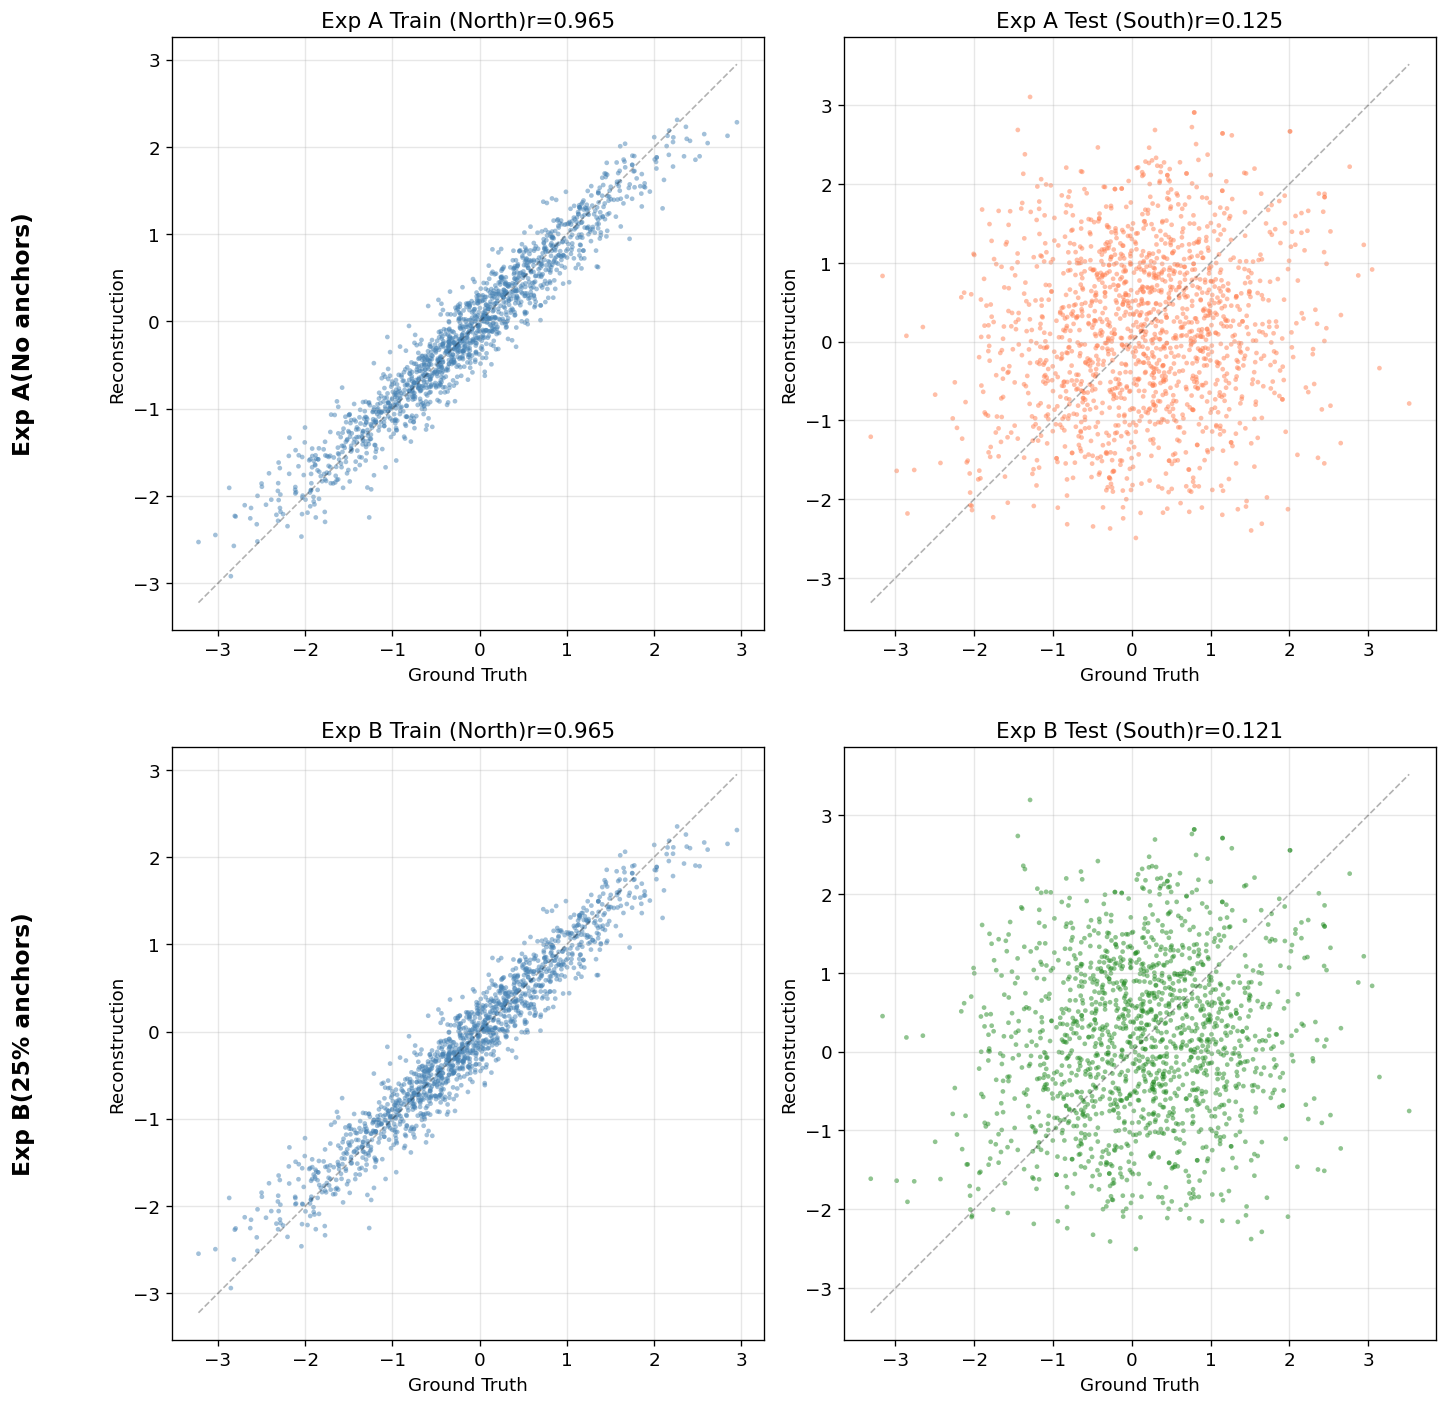

Conclusion / Conclusion:
Exp A: Surface data alone cannot constrain radial structure
Exp B: 3D anchors effectively break projection degeneracy
Exp A: Surface data alone cannot constrain radial structure
Exp B: 3D anchors effectively break projection degeneracy


In [5]:
# ── Computing重建图 / Compute reconstruction maps ────────────
def get_recon_map(phi_flat):
    phi3d = phi_flat.reshape(N_vox, N_vox, N_vox)
    phi_f = dsc_forward(phi3d, n_steps)
    return np.array(project_hp(phi_f))

recon_A = get_recon_map(phi_A)
recon_B = get_recon_map(phi_B)

# ── ComputingCorrelation / Compute correlations ──────────────────
r_A_train = np.corrcoef(target_full[north_mask], recon_A[north_mask])[0,1]
r_A_test  = np.corrcoef(target_full[south_mask], recon_A[south_mask])[0,1]
r_B_train = np.corrcoef(target_full[north_mask], recon_B[north_mask])[0,1]
r_B_test  = np.corrcoef(target_full[south_mask], recon_B[south_mask])[0,1]

print("=" * 60)
print("Correlation / Correlation coefficients:")
print(f"  Exp A (North Hemisphere only):  train r={r_A_train:.4f}, test r={r_A_test:.4f}")
print(f"  Exp B (North Hemisphere+Anchors):  train r={r_B_train:.4f}, test r={r_B_test:.4f}")
print("=" * 60)
print(f"\
Expected / Expected: A test ~ -0.06, B test ~ 0.41")

# ── 2x2 散点图 / 2x2 scatter plots (Fig 15) ────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

panels = [
    (axes[0,0], target_full[north_mask], recon_A[north_mask],
     f'Exp A Train (North)\
r={r_A_train:.3f}', 'steelblue'),
    (axes[0,1], target_full[south_mask], recon_A[south_mask],
     f'Exp A Test (South)\
r={r_A_test:.3f}', 'coral'),
    (axes[1,0], target_full[north_mask], recon_B[north_mask],
     f'Exp B Train (North)\
r={r_B_train:.3f}', 'steelblue'),
    (axes[1,1], target_full[south_mask], recon_B[south_mask],
     f'Exp B Test (South)\
r={r_B_test:.3f}', 'forestgreen'),
]

for ax, truth, pred, title, color in panels:
    ax.scatter(truth, pred, s=8, alpha=0.5, c=color, edgecolors='none')
    lims = [min(truth.min(), pred.min()), max(truth.max(), pred.max())]
    ax.plot(lims, lims, 'k--', alpha=0.3, lw=1)
    ax.set_xlabel('Ground Truth')
    ax.set_ylabel('Reconstruction')
    ax.set_title(title, fontsize=13)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

# / Add row labels
axes[0,0].annotate('Exp A\
(No anchors)', xy=(-0.25, 0.5),
                    xycoords='axes fraction', fontsize=14, ha='center',
                    va='center', rotation=90, fontweight='bold')
axes[1,0].annotate('Exp B\
(25% anchors)', xy=(-0.25, 0.5),
                    xycoords='axes fraction', fontsize=14, ha='center',
                    va='center', rotation=90, fontweight='bold')

plt.tight_layout()
plt.savefig('fig15_degeneracy_breaking.png', dpi=150, bbox_inches='tight')
plt.show()

print("\
Conclusion / Conclusion:")
print("Exp A: Surface data alone cannot constrain radial structure")
print("Exp B: 3D anchors effectively break projection degeneracy")
print("Exp A: Surface data alone cannot constrain radial structure")
print("Exp B: 3D anchors effectively break projection degeneracy")